In [1]:
# Install windrose (for wind rose plots)
!pip install windrose

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from windrose import WindroseAxes

print("Libraries loaded!")


Libraries loaded!


In [32]:
# Path to your CSV file
file_path = '/content/sierraleone-bumbuna.csv'

# Load CSV into DataFrame
df = pd.read_csv(file_path)

# Convert Timestamp to datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

# Quick preview
print("First 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-10-30 00:01:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2021-10-30 00:02:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2021-10-30 00:03:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2021-10-30 00:04:00,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
2021-10-30 00:05:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [33]:
# Numeric summary
print("Summary Statistics:")
display(df.describe())

# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

print("Columns with missing values:")
display(missing[missing > 0])

print("Columns with >5% missing:")
display(missing_percent[missing_percent > 5])


Summary Statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN


Columns with missing values:


,0
Comments,525600


Columns with >5% missing:


,0
Comments,100.0


In [34]:
cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

# Flag rows with |Z| > 3
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outlier rows: {outliers.sum()}")

# View outliers
df_outliers = df[outliers]
display(df_outliers)


Number of outlier rows: 16292


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-10-30 10:54:00,814.0,257.0,594.3,878.0,856.0,25.9,85.3,0.5,1.1,0.5,81.4,7.9,1002,0,0.0,50.4,45.6,NaN
2021-10-30 10:55:00,826.0,263.5,599.6,883.0,861.0,26.0,85.4,1.7,2.4,0.4,74.6,12.1,1002,0,0.0,51.6,46.6,NaN
2021-10-30 10:56:00,851.0,285.0,605.9,912.0,890.0,26.0,84.2,1.6,2.1,0.5,66.4,14.6,1002,0,0.0,52.4,47.0,NaN
2021-10-30 10:57:00,823.0,254.8,603.9,878.0,856.0,26.0,85.3,0.8,1.6,0.6,90.2,7.0,1002,0,0.0,53.4,47.7,NaN
2021-10-30 10:58:00,810.0,244.5,598.8,864.0,843.0,26.1,85.7,0.6,1.6,0.6,108.5,7.9,1002,0,0.0,54.6,48.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-27 15:05:00,167.2,-0.5,165.1,167.6,160.9,30.4,68.3,5.3,6.7,0.9,147.9,10.1,999,0,0.0,36.4,36.4,NaN
2022-10-27 15:06:00,163.4,-0.6,161.0,165.7,159.2,30.2,67.7,7.1,8.4,0.8,144.5,7.7,999,0,0.0,35.6,35.6,NaN
2022-10-27 15:15:00,183.5,0.3,181.6,173.7,168.7,29.3,70.2,4.9,5.9,0.7,128.7,14.9,999,0,0.0,35.3,35.1,NaN


In [35]:
# Copy to clean
df_clean = df.copy()

# Replace outliers with median
for col in cols:
    median = df_clean[col].median()
    df_clean[col] = df_clean[col].mask(z_scores[:, cols.index(col)] > 3, median)

# Fill missing values with median
for col in cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Cleaning complete.")
df_clean.describe()


Cleaning complete.


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.00000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,196.44199,104.527217,110.109541,203.054922,193.719867,26.319394,79.448857,1.106696,1.644945,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,291.23529,201.696328,154.170508,296.230534,283.124918,4.398605,20.520775,1.157374,1.509352,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.50000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.80000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.30000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,353.90000,75.500000,220.400000,353.800000,338.500000,29.400000,96.700000,1.900000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1097.00000,772.300000,590.500000,1109.200000,1064.000000,39.900000,100.000000,4.800000,6.400000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN


In [36]:
clean_file = '/content/sierraleone_clean.csv'
df_clean.to_csv(clean_file, index=False)
print(f"Cleaned data saved to {clean_file}")


Cleaned data saved to /content/sierraleone_clean.csv


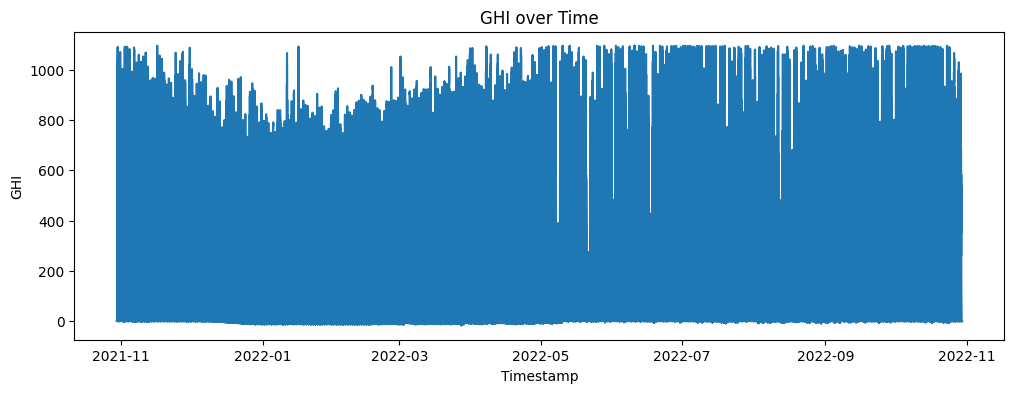

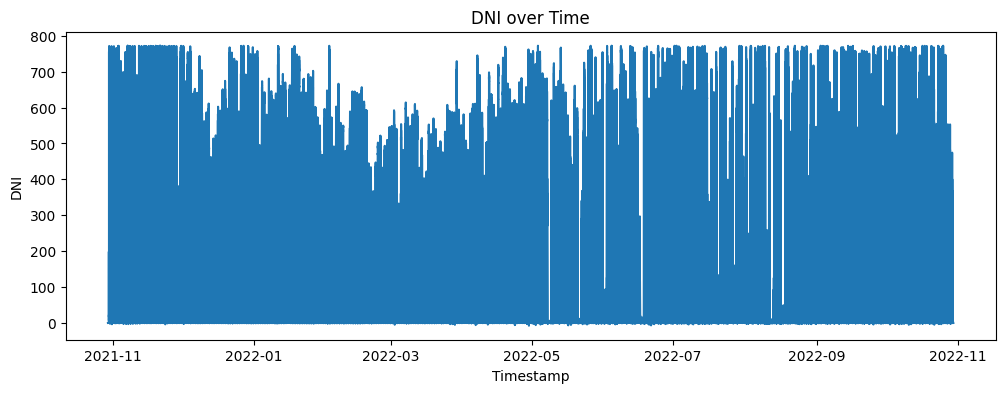

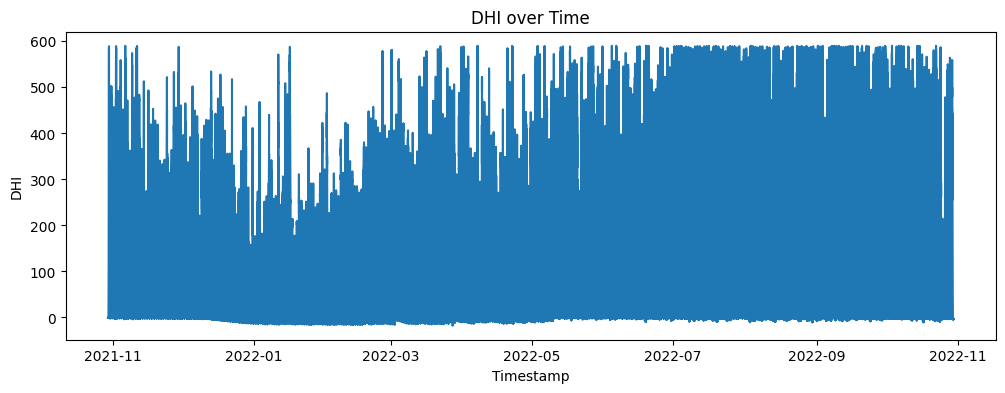

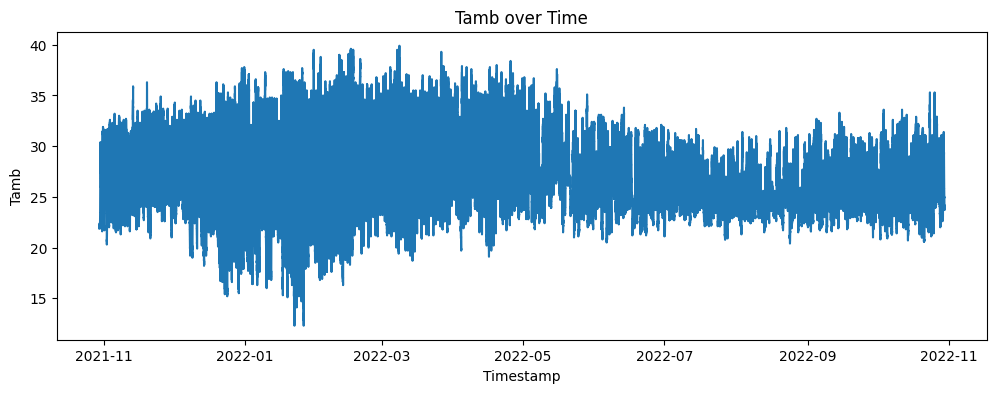

In [37]:
for col in ['GHI','DNI','DHI','Tamb']:
    plt.figure(figsize=(12,4))
    plt.plot(df_clean[col])
    plt.title(f"{col} over Time")
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.show()


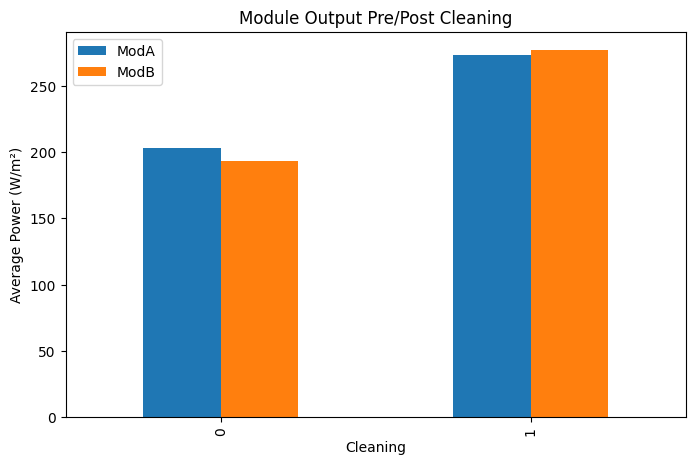

In [38]:
if 'Cleaning' in df_clean.columns:
    df_clean.groupby('Cleaning')[['ModA','ModB']].mean().plot(kind='bar', figsize=(8,5))
    plt.title("Module Output Pre/Post Cleaning")
    plt.ylabel("Average Power (W/m²)")
    plt.show()


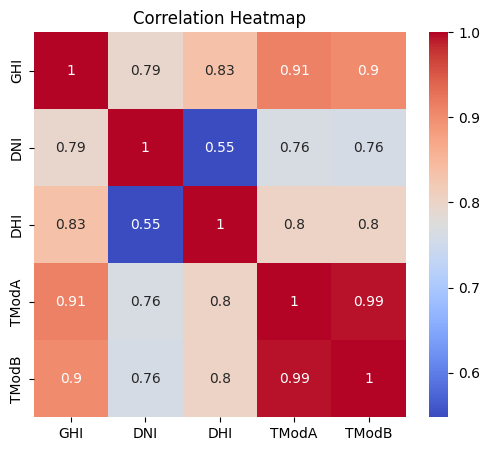

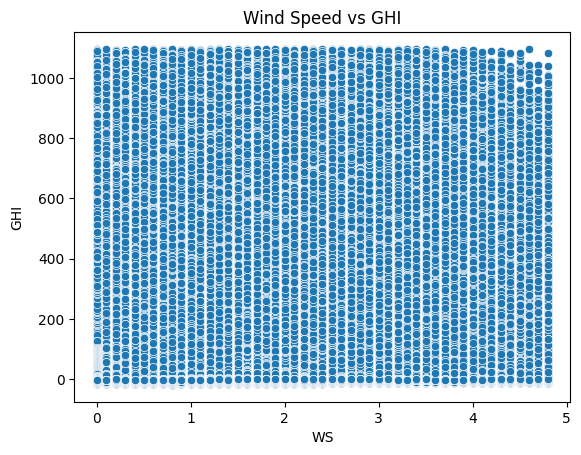

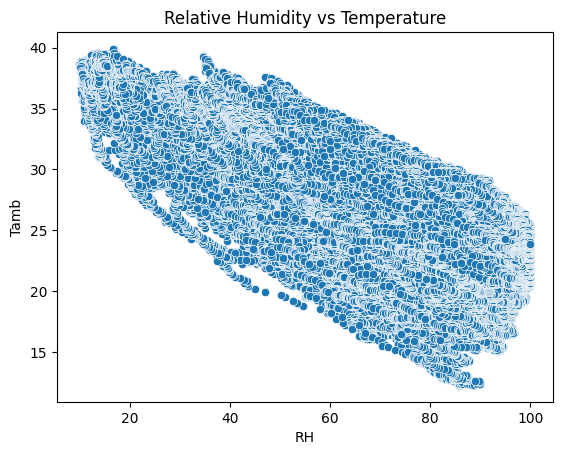

In [39]:
# Correlation heatmap
corr_cols = ['GHI','DNI','DHI','TModA','TModB']
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots
sns.scatterplot(data=df_clean, x='WS', y='GHI')
plt.title("Wind Speed vs GHI")
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("Relative Humidity vs Temperature")
plt.show()


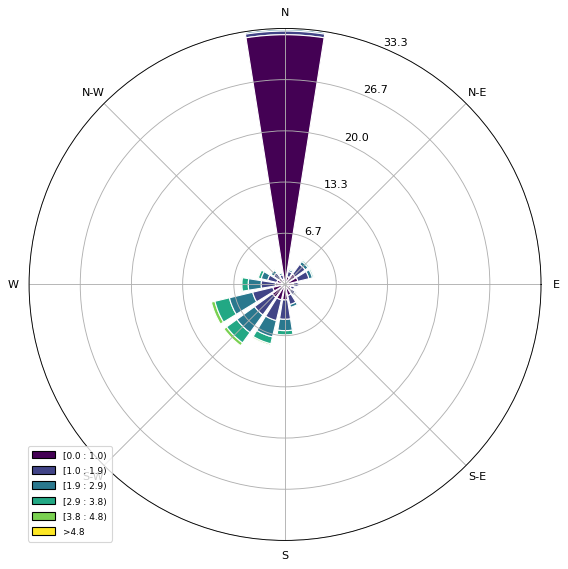

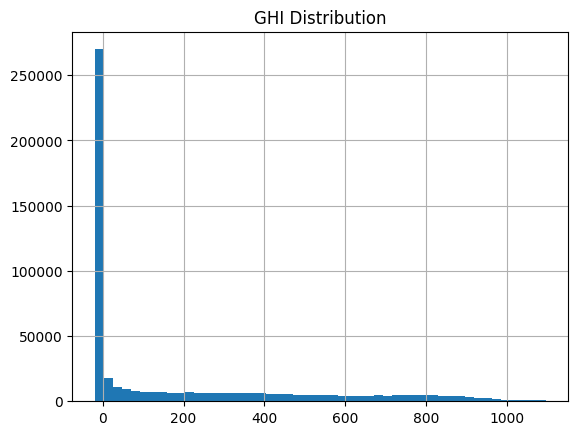

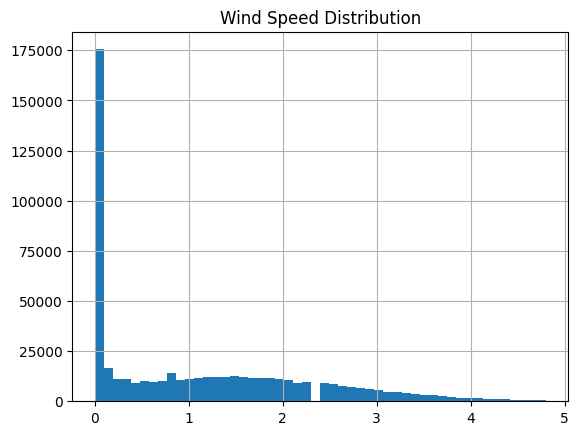

In [40]:
# Wind rose plot
if 'WD' in df_clean.columns and 'WS' in df_clean.columns:
    ax = WindroseAxes.from_ax()
    ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
    ax.set_legend()
    plt.show()

# Histograms
df_clean['GHI'].hist(bins=50)
plt.title("GHI Distribution")
plt.show()

df_clean['WS'].hist(bins=50)
plt.title("Wind Speed Distribution")
plt.show()


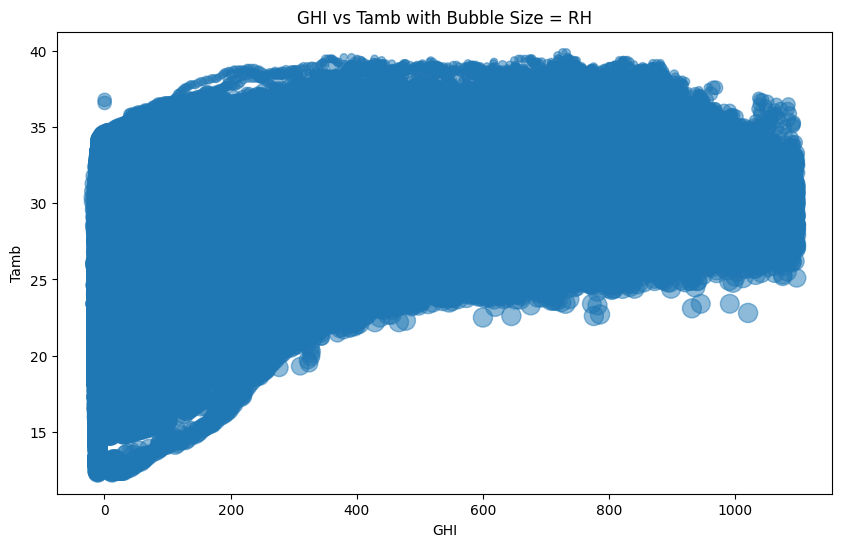

In [41]:
if 'RH' in df_clean.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH']*2, alpha=0.5)
    plt.xlabel('GHI')
    plt.ylabel('Tamb')
    plt.title('GHI vs Tamb with Bubble Size = RH')
    plt.show()
